In [ ]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

ROOT = Path('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2')
sys.path.append(str(ROOT / 'src'))

from loading_data.data_catalogue import DataCatalogue

dc = DataCatalogue()
dd = dc.get_data_dict()

all_vars = [k for k, v in dc.get_data_dict().items() 
            if not v.get('target') 
            and not v.get('geographic')
            and k not in ['year', 'month']]
print(all_vars)

['Gend3', 'Disab2_POP', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'Child4', 'WorkStat8', 'HHLiv9', 'Motiva_POP', 'motivd_POP', 'indev', 'indevtry', 'inclus_a', 'inclus_b', 'inclus_c', 'comm1', 'comm2', 'anxious', 'happy', 'lone', 'worthw']


In [75]:
df = pd.read_csv(ROOT / 'exploration' / 'data' / 'master_data' / '2016_to_2023_master_clustering_data_set.csv')

available = [v for v in all_vars if v in df.columns] + ['MEMS7_ALL']
df_analysis = df[available].dropna()

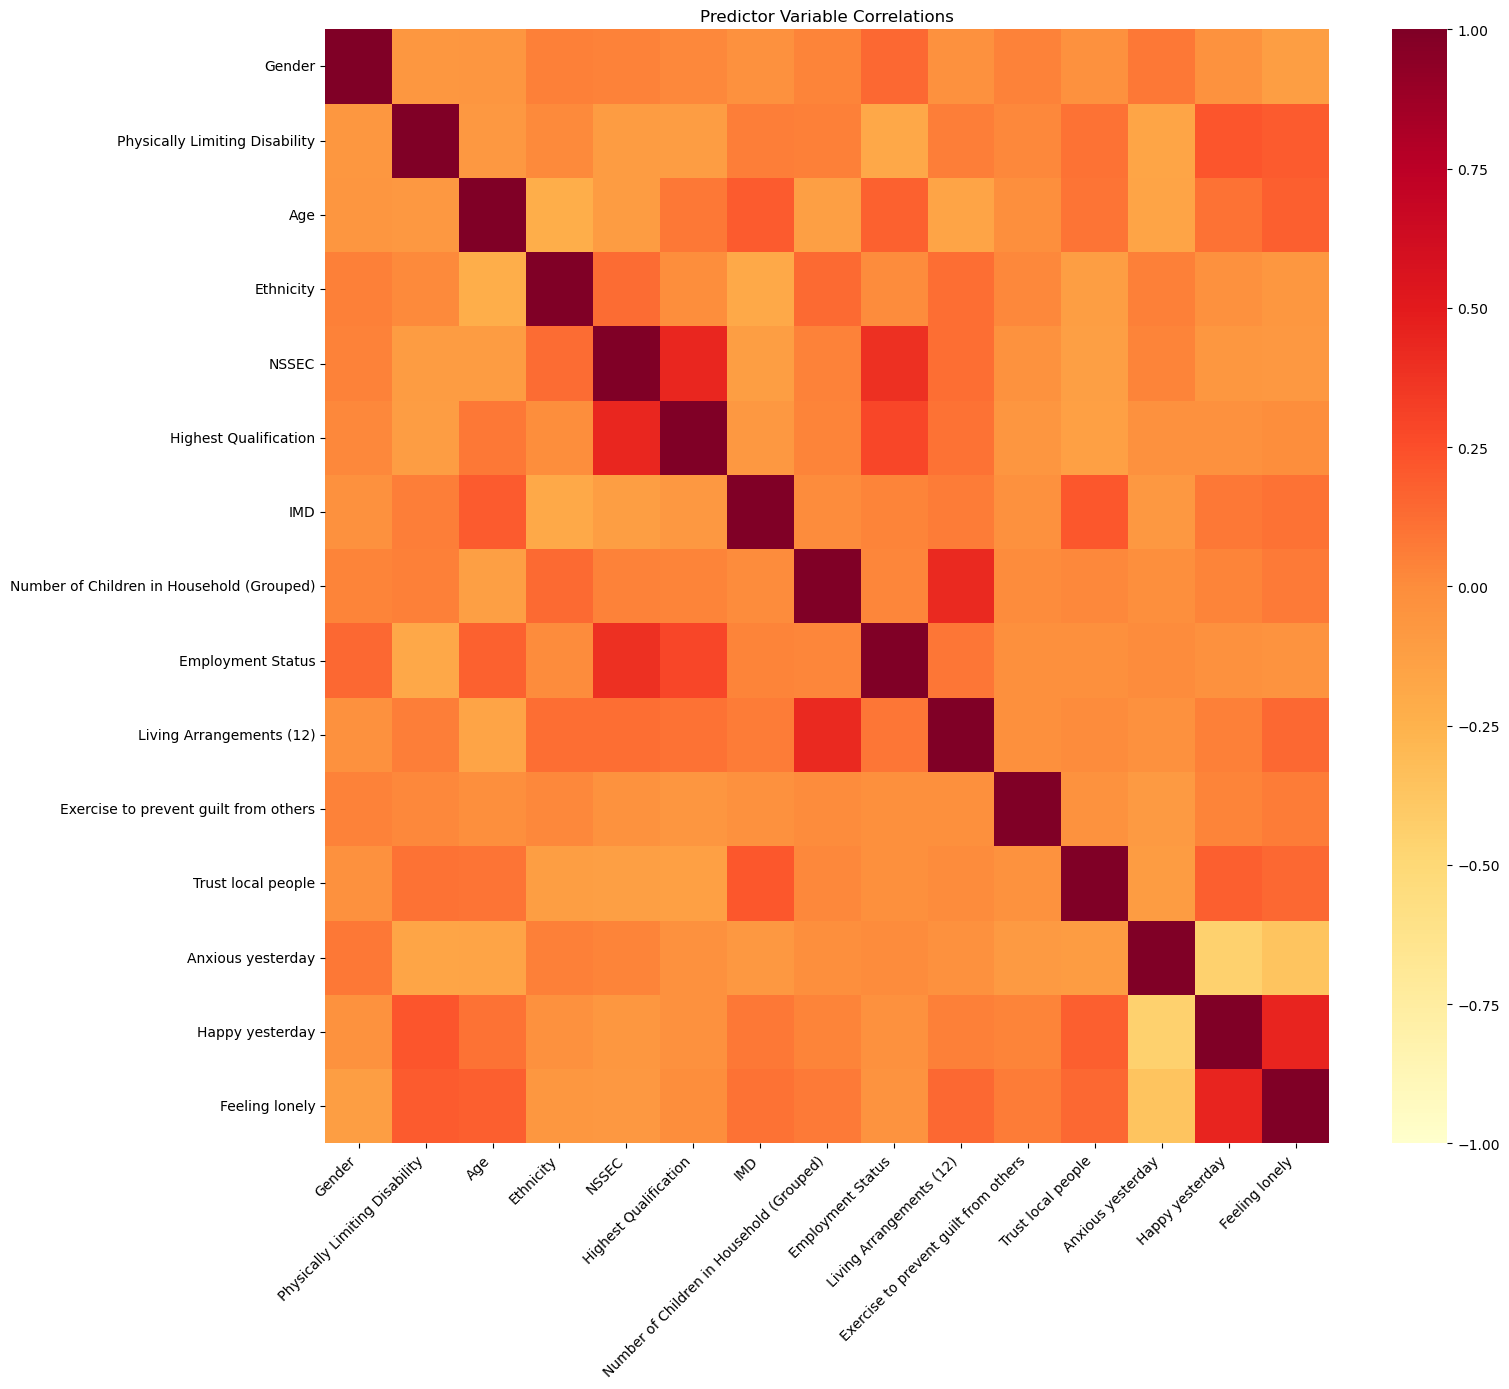

In [77]:
corr_vars = [v for v in available if v != 'MEMS7_ALL']
corr_matrix = df_analysis[corr_vars].corr(method='spearman')

labels = [dd[v]['graph_label'] for v in corr_vars]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, 
            xticklabels=labels, 
            yticklabels=labels,
            cmap='YlOrRd', 
            vmin=-1, vmax=1,
            annot=False,
            ax=ax)
ax.set_title('Predictor Variable Correlations')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

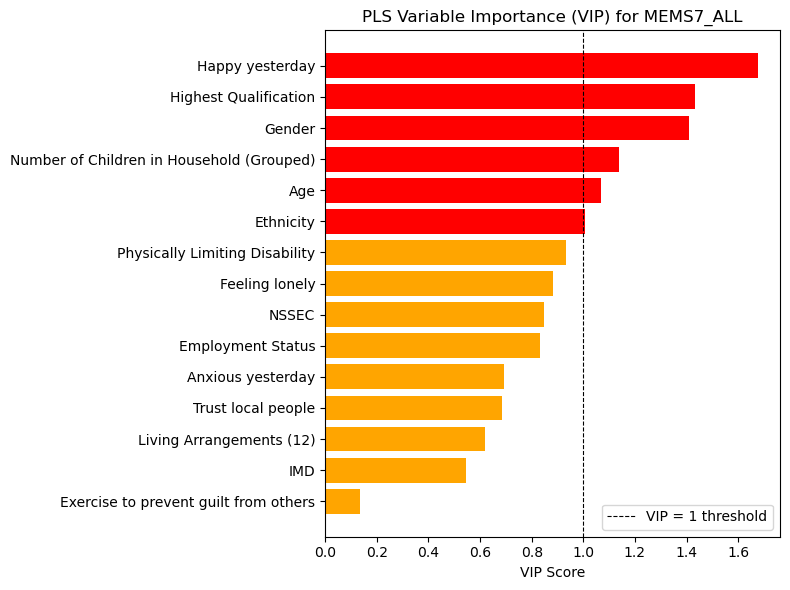

In [81]:
X = df_analysis[corr_vars].values
y = df_analysis['MEMS7_ALL'].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

pls = PLSRegression(n_components=2)
pls.fit(X_scaled, y_scaled)

def vip(model):
    t = model.x_scores_
    w = model.x_weights_
    q = model.y_loadings_
    p, h = w.shape
    vips = np.zeros((p,))
    s = np.diag(t.T @ t @ q.T @ q)
    total_s = np.sum(s)
    for i in range(p):
        weight = np.array([(w[i, j] / np.linalg.norm(w[:, j]))**2 for j in range(h)])
        vips[i] = np.sqrt(p * np.dot(s, weight) / total_s)
    return vips

vip_scores = vip(pls)
vip_df = pd.DataFrame({
    'var': corr_vars,
    'label': [dd[v]['graph_label'] for v in corr_vars],
    'vip': vip_scores
}).sort_values('vip', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['orange' if v < 1 else 'red' for v in vip_df['vip']]
ax.barh(vip_df['label'], vip_df['vip'], color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=0.8, label='VIP = 1 threshold')
ax.set_xlabel('VIP Score')
ax.set_title('PLS Variable Importance (VIP) for MEMS7_ALL')
ax.legend()
plt.tight_layout()
plt.savefig('pls_vip.png', dpi=150)
plt.show()